Importing and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
collisions = pd.read_csv("dft-road-casualty-statistics-collision-2024.csv")
vehicles = pd.read_csv("dft-road-casualty-statistics-vehicle-2024.csv")
casualties = pd.read_csv("dft-road-casualty-statistics-casualty-2024.csv")

C:\Users\aayus\AppData\Local\Temp\ipykernel_564\274019158.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  collisions = pd.read_csv("dft-road-casualty-statistics-collision-2024.csv")
C:\Users\aayus\AppData\Local\Temp\ipykernel_564\274019158.py:2: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles = pd.read_csv("dft-road-casualty-statistics-vehicle-2024.csv")


In [3]:
print(collisions.shape)
print(vehicles.shape)
print(casualties.shape)

(100927, 44)
(183514, 32)
(128272, 23)


Merging the files

In [4]:
print("Collision cols:", collisions.columns.tolist())
print("\nVehicle cols:",  vehicles.columns.tolist())
print("\nCasualty cols:", casualties.columns.tolist())

Collision cols: ['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision

In [5]:
df = collisions.merge(vehicles, on = "collision_index", how = "left") \
      .merge(casualties, on = "collision_index", how = "left")

In [6]:
df.shape

(171352, 97)

Drop duplicate columns from the merge

In [7]:
dupe_cols = [col for col in df.columns if col.endswith("_y")]
df = df.drop(columns=dupe_cols)

df.columns = [col.replace("_x", "") for col in df.columns]

In [8]:
df.shape

(171352, 94)

Drop low-value columns

In [9]:
cols_to_drop = [
    "collision_ref_no", "location_easting_osgr", "location_northing_osgr",
    "local_authority_ons_district", "local_authority_highway",
    "local_authority_highway_current", "first_road_number", "second_road_number",
    "lsoa_of_accident_location", "lsoa_of_driver", "lsoa_of_casualty",
    "driver_imd_decile", "casualty_imd_decile", "trunk_road_flag",
    "pedestrian_road_maintenance_worker", "escooter_flag",
    "junction_detail_historic", "vehicle_manoeuvre_historic",
    "vehicle_location_restricted_lane_historic", "journey_purpose_of_driver_historic",
    "pedestrian_crossing_human_control_historic",
    "pedestrian_crossing_physical_facilities_historic",
    "carriageway_hazards_historic"
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

In [13]:
df.shape

(171352, 70)

Date and Time

In [10]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")

df["hour"] = df["time"].str[:2].astype(float)
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

In [11]:
print(df[["date", "time", "hour", "month", "day_of_week"]].head(10))

        date   time  hour  month day_of_week
0 2024-12-05  16:10  16.0     12    Thursday
1 2024-12-05  16:10  16.0     12    Thursday
2 2024-10-22  14:56  14.0     10     Tuesday
3 2024-01-24  17:50  17.0      1   Wednesday
4 2024-01-24  17:50  17.0      1   Wednesday
5 2024-05-22  17:45  17.0      5   Wednesday
6 2024-08-11  15:36  15.0      8      Sunday
7 2024-08-11  15:36  15.0      8      Sunday
8 2024-03-19  14:40  14.0      3     Tuesday
9 2024-03-19  14:40  14.0      3     Tuesday


Handling Null Values

In [12]:
print(df.isnull().sum().sort_values(ascending=False).head(15))

skidding_and_overturning              51775
hit_object_in_carriageway             51775
junction_location                     51775
vehicle_location_restricted_lane      51775
vehicle_direction_to                  51775
vehicle_direction_from                51775
vehicle_manoeuvre                     51775
towing_and_articulation               51775
casualty_type                         51775
enhanced_casualty_severity            51775
casualty_injury_based                 51775
casualty_adjusted_severity_serious    51775
casualty_adjusted_severity_slight     51775
casualty_distance_banding             51775
car_passenger                         51775
dtype: int64


In [13]:
core_cols = ["collision_severity", "weather_conditions", "road_type", 
             "light_conditions", "hour", "speed_limit","generic_make_model","age_of_vehicle","age_of_driver","sex_of_driver"]


df_clean = df.dropna(subset=core_cols)

print("Shape before:", df.shape)
print("Shape after:",  df_clean.shape)
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

Shape before: (171352, 72)
Shape after: (119577, 72)
Rows dropped: 51775


In [14]:
df_clean[core_cols].dtypes

collision_severity      int64
weather_conditions      int64
road_type               int64
light_conditions        int64
hour                  float64
speed_limit             int64
generic_make_model     object
age_of_vehicle        float64
age_of_driver         float64
sex_of_driver         float64
dtype: object

In [15]:
for col in core_cols:
    print(f"\n{col}:{df[col].unique()}")


collision_severity:[3 2 1]

weather_conditions:[2 1 5 9 8 4 7 3 6]

road_type:[6 3 1 2 7 9]

light_conditions:[ 4  1  6  5  7 -1]

hour:[16. 14. 17. 15.  8. 19. 20.  7. 21.  6. 11.  9. 18.  1. 22. 13. 10.  4.
  0. 12.  5.  2. 23.  3.]

speed_limit:[30 50 40 70 60 20 -1]

generic_make_model:['SEAT ARONA' 'KIA CEED' 'ALEXANDER DENNIS MODEL MISSING' 'KIA SOUL'
 'FORD KUGA' 'MERCEDES SPRINTER' 'YAMAHA FZS' -1 'SUZUKI SWIFT'
 'FORD TRANSIT CONNECT' 'FORD S-MAX' 'TESLA MODEL 3' 'BMW 1 SERIES'
 'FORD FOCUS' 'AUDI Q5' 'BMW X1' 'VOLKSWAGEN GOLF' 'HONDA HR-V' '-1'
 'HYUNDAI I10' 'VOLKSWAGEN POLO' 'AUDI A5' 'NISSAN JUKE' 'TOYOTA YARIS'
 'PEUGEOT 407' 'DAF TRUCKS MODEL MISSING' 'NISSAN NOTE' 'FIAT PUNTO'
 'PIAGGIO LIBERTY' 'LEXMOTO LXR' 'AUDI A1' 'SUZUKI GSX 650' 'AUDI A4'
 'AUDI Q3' 'HYUNDAI I30' 'HONDA NSC' 'MINI COOPER' 'AUDI A6'
 'MERCEDES E CLASS' 'FORD TRANSIT CUSTOM' 'YAMAHA YZF' 'VAUXHALL ASTRA'
 'PEUGEOT PARTNER' 'CITROEN C3' 'BMW IX' 'CITROEN C4' 'YAMAHA YBR'
 'RENAULT MODUS' 'PIAGGIO V

In [16]:
df_clean[core_cols].head(10)

,collision_severity,weather_conditions,road_type,light_conditions,hour,speed_limit,generic_make_model,age_of_vehicle,age_of_driver,sex_of_driver
0,3,2,6,4,16.0,30,SEAT ARONA,1.0,35.0,1.0
1,3,2,6,4,16.0,30,KIA CEED,13.0,-1.0,1.0
2,3,1,6,1,14.0,30,ALEXANDER DENNIS MODEL MISSING,10.0,-1.0,1.0
3,3,1,6,4,17.0,30,KIA SOUL,15.0,45.0,1.0
4,3,1,6,4,17.0,30,FORD KUGA,10.0,-1.0,2.0
5,2,5,6,1,17.0,50,MERCEDES SPRINTER,12.0,66.0,1.0
6,2,1,3,1,15.0,50,YAMAHA FZS,21.0,24.0,1.0
7,2,1,3,1,15.0,50,-1,-1.0,37.0,1.0
8,3,9,6,1,14.0,40,SUZUKI SWIFT,17.0,-1.0,2.0
9,3,9,6,1,14.0,40,SUZUKI SWIFT,17.0,-1.0,2.0


In [17]:
df_clean = df.copy()
df_clean["age_of_vehicle"] = df_clean["age_of_vehicle"].replace(-1, np.nan)
df_clean["age_of_driver"]  = df_clean["age_of_driver"].replace(-1, np.nan)
df_clean["sex_of_driver"]  = df_clean["sex_of_driver"].replace(-1, np.nan)

In [18]:
df_clean["generic_make_model"] = df_clean["generic_make_model"].replace("-1", np.nan)
df_clean["generic_make_model"] = df_clean["generic_make_model"].replace(
    to_replace=r".*(MODEL MISSING|REDACTED).*", 
    value=np.nan, 
    regex=True
)

In [19]:
sex_map = {1: "Male", 2: "Female", 3: "Not known"}
df_clean["sex_of_driver"] = df_clean["sex_of_driver"].map(sex_map)

In [20]:
for col in ["age_of_vehicle", "age_of_driver", "sex_of_driver", "generic_make_model"]:
    print(f"  {col}: {(df_clean[col] == -1).sum()} | nulls: {df_clean[col].isnull().sum()}")

  age_of_vehicle: 0 | nulls: 80690
  age_of_driver: 0 | nulls: 68280
  sex_of_driver: 0 | nulls: 54364
  generic_make_model: 18676 | nulls: 66539


In [21]:
df_clean["sex_of_driver"].value_counts()

sex_of_driver
Male         73613
Female       32798
Not known    10577
Name: count, dtype: int64

In [22]:
df_clean["generic_make_model"].value_counts().head(10)

generic_make_model
-1                 18676
FORD FIESTA         3456
VAUXHALL CORSA      2886
VOLKSWAGEN GOLF     2588
FORD FOCUS          2404
VAUXHALL ASTRA      1853
VOLKSWAGEN POLO     1658
NISSAN QASHQAI      1399
TOYOTA YARIS        1381
BMW 3 SERIES        1361
Name: count, dtype: int64

In [23]:
df_clean["generic_make_model"] = df_clean["generic_make_model"].astype(str)  # convert everything to string first
df_clean["generic_make_model"] = df_clean["generic_make_model"].str.strip()  # remove whitespace

# Now replace all bad values
bad_values = ["-1", "nan", "NAN", "None"]
df_clean["generic_make_model"] = df_clean["generic_make_model"].replace(bad_values, np.nan)

# Replace MODEL MISSING and REDACTED variants
df_clean["generic_make_model"] = df_clean["generic_make_model"].replace(
    to_replace=r".*(MODEL MISSING|REDACTED).*",
    value=np.nan,
    regex=True
)

In [24]:
df_clean["generic_make_model"].value_counts().head(10)

generic_make_model
FORD FIESTA        3456
VAUXHALL CORSA     2886
VOLKSWAGEN GOLF    2588
FORD FOCUS         2404
VAUXHALL ASTRA     1853
VOLKSWAGEN POLO    1658
NISSAN QASHQAI     1399
TOYOTA YARIS       1381
BMW 3 SERIES       1361
AUDI A3            1260
Name: count, dtype: int64

In [25]:
df_clean = df_clean.dropna(subset=core_cols)
print("Shape after: ", df_clean.shape)
print("Rows dropped:", 171352 - df_clean.shape[0])

Shape after:  (76575, 72)
Rows dropped: 94777


### Information of final cleaned dataset

In [48]:
df_clean.head()

,collision_index,collision_year,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,...,car_passenger,bus_or_coach_passenger,casualty_type,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding,hour,month
0,202417M119024,2024,-1.22722,54.57219,17,3,2,1,2024-12-05,Thursday,...,1.0,0.0,9.0,3.0,1.0,0.00000,1.00000,1.0,16.0,12
3,2024070110901,2024,-2.53157,53.41443,7,3,2,1,2024-01-24,Wednesday,...,0.0,0.0,9.0,-1.0,0.0,0.01474,0.98526,1.0,17.0,1
5,2024041446676,2024,-2.51630,53.67359,4,2,1,1,2024-05-22,Wednesday,...,0.0,0.0,19.0,6.0,1.0,1.00000,0.00000,2.0,17.0,5
6,2024041478641,2024,-2.50416,53.76592,4,2,2,1,2024-08-11,Sunday,...,0.0,0.0,5.0,7.0,1.0,1.00000,0.00000,1.0,15.0,8
12,2024161438773,2024,-0.66503,53.57841,16,3,1,1,2024-05-03,Friday,...,0.0,0.0,0.0,3.0,1.0,0.00000,1.00000,4.0,8.0,5


In [49]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76575 entries, 0 to 119575
Data columns (total 72 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   collision_index                              76575 non-null  object        
 1   collision_year                               76575 non-null  int64         
 2   longitude                                    76575 non-null  float64       
 3   latitude                                     76575 non-null  float64       
 4   police_force                                 76575 non-null  int64         
 5   collision_severity                           76575 non-null  int64         
 6   number_of_vehicles                           76575 non-null  int64         
 7   number_of_casualties                         76575 non-null  int64         
 8   date                                         76575 non-null  datetime64[ns]
 9  

In [50]:
df_clean.describe()

,collision_year,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,local_authority_district,first_road_class,...,car_passenger,bus_or_coach_passenger,casualty_type,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding,hour,month
count,76575.0,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575,76575.0,76575.000000,...,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000,76575.000000
mean,2024.0,-1.997836,52.904590,32.981012,2.694770,2.198263,1.938374,2024-07-07 05:37:20.673849088,-1.0,4.091388,...,0.302919,0.023389,8.075455,2.331727,0.711198,0.209962,0.776274,1.461495,13.933673,6.701874
min,2024.0,-7.383540,49.912210,1.000000,1.000000,1.000000,1.000000,2024-01-01 00:00:00,-1.0,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,1.000000
25%,2024.0,-2.792170,51.568730,12.000000,2.000000,2.000000,1.000000,2024-04-13 00:00:00,-1.0,3.000000,...,0.000000,0.000000,9.000000,-1.000000,0.000000,0.000000,0.880710,1.000000,11.000000,4.000000
50%,2024.0,-1.907700,52.639490,20.000000,3.000000,2.000000,1.000000,2024-07-07 00:00:00,-1.0,3.000000,...,0.000000,0.000000,9.000000,3.000000,1.000000,0.000000,1.000000,1.000000,15.000000,7.000000
75%,2024.0,-1.159425,53.725080,52.000000,3.000000,2.000000,2.000000,2024-10-04 00:00:00,-1.0,6.000000,...,0.000000,0.000000,9.000000,3.000000,1.000000,0.104005,1.000000,2.000000,17.000000,10.000000
max,2024.0,0.792890,60.344800,99.000000,3.000000,16.000000,20.000000,2024-12-31 00:00:00,-1.0,6.000000,...,9.000000,4.000000,99.000000,7.000000,1.000000,1.000000,1.000000,5.000000,23.000000,12.000000
std,0.0,1.248292,1.543931,27.566565,0.509897,1.030954,1.355262,NaN,0.0,1.490686,...,0.621730,0.301941,6.739282,2.454559,0.453209,0.386837,0.396784,1.586034,5.026973,3.367984


## PLOTTING

Accidents by hour of day

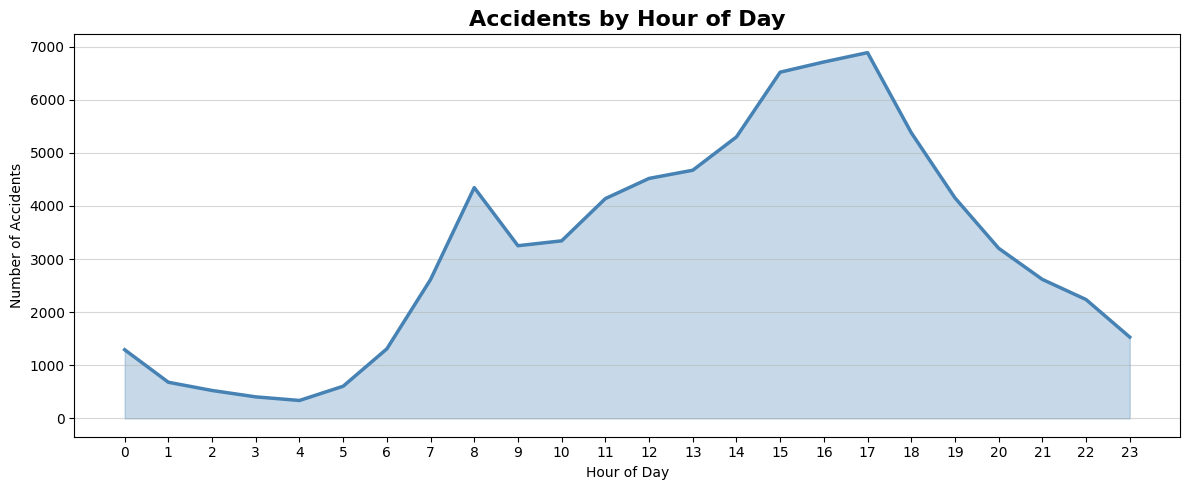

In [26]:
plt.figure(figsize=(12, 5))

hourly = df_clean["hour"].value_counts().sort_index()

sns.lineplot(x=hourly.index, y=hourly.values, color="steelblue", linewidth=2.5)
plt.fill_between(hourly.index, hourly.values, alpha=0.3, color="steelblue")

plt.title("Accidents by Hour of Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.savefig("plot1_hourly_accidents.png", dpi=150)
plt.show()

Accidents by week of day

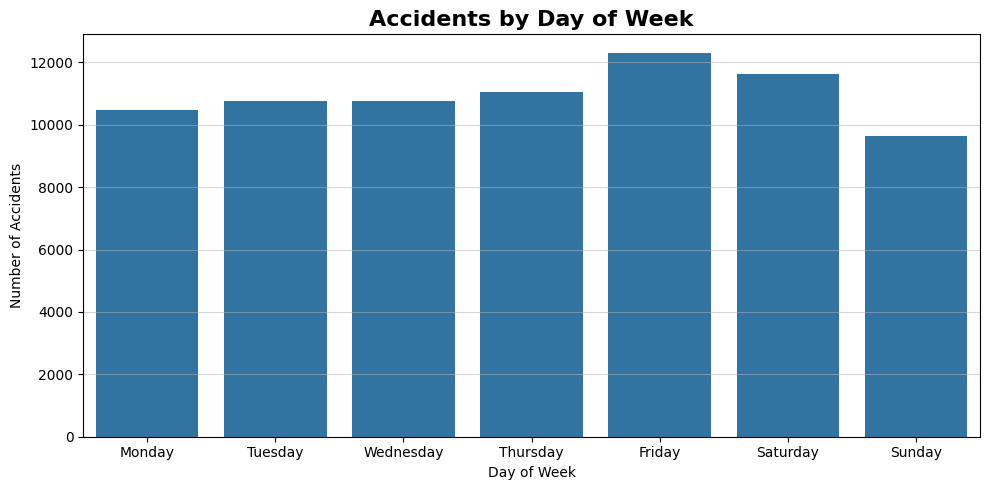

In [55]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_clean["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(10,5))
sns.barplot(x=day_counts.index, y= day_counts.values)
plt.title("Accidents by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.grid(axis="y",alpha=0.5)

plt.tight_layout()
plt.savefig("plot2_daily_accidents.png", dpi=150)
plt.show()

Accidents by month

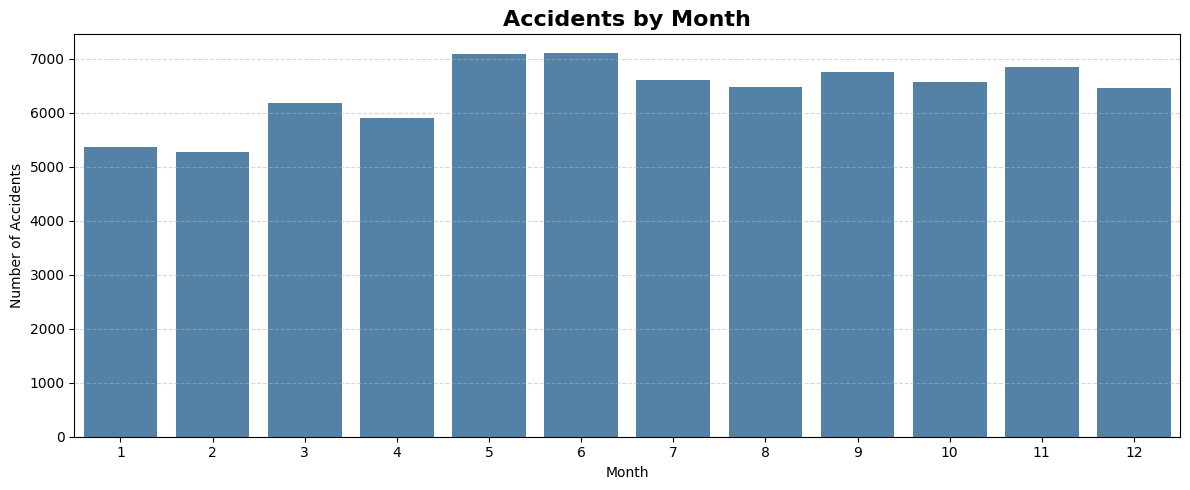

In [61]:
month_counts = df_clean["month"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=month_counts.index, y=month_counts.values, color="steelblue")
plt.title("Accidents by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plot3_monthly_accidents.png", dpi=150)
plt.show()

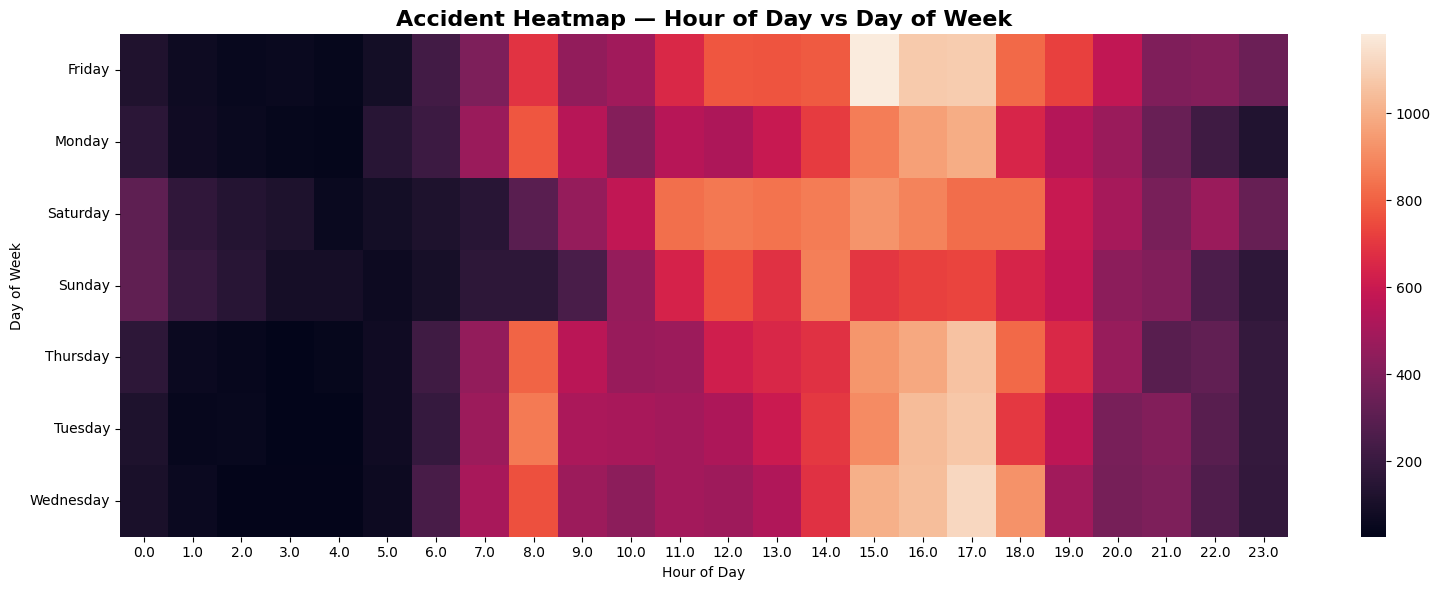

In [69]:
pivot = df_clean.pivot_table(index = "day_of_week",columns="hour",values = "collision_index", aggfunc = "count")
pivot = pivot.sort_index()
plt.figure(figsize=(16, 6))
sns.heatmap(pivot)
plt.title("Accident Heatmap — Hour of Day vs Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig("plot4_heatmap_hour_day.png", dpi=150)
plt.show()

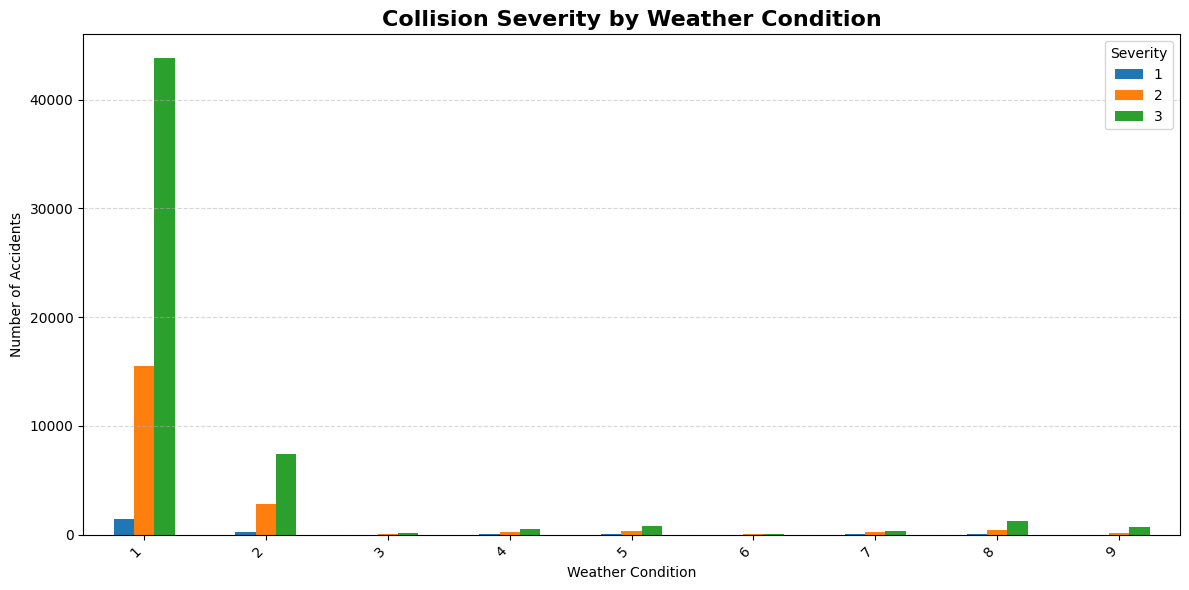

In [72]:
weather_severity = df_clean.groupby(["weather_conditions", "collision_severity"]).size().unstack(fill_value=0)

weather_severity.plot(kind="bar", figsize=(12, 6))
plt.title("Collision Severity by Weather Condition", fontsize=16, fontweight="bold")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Severity")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plot6_severity_by_weather.png", dpi=150)
plt.show()

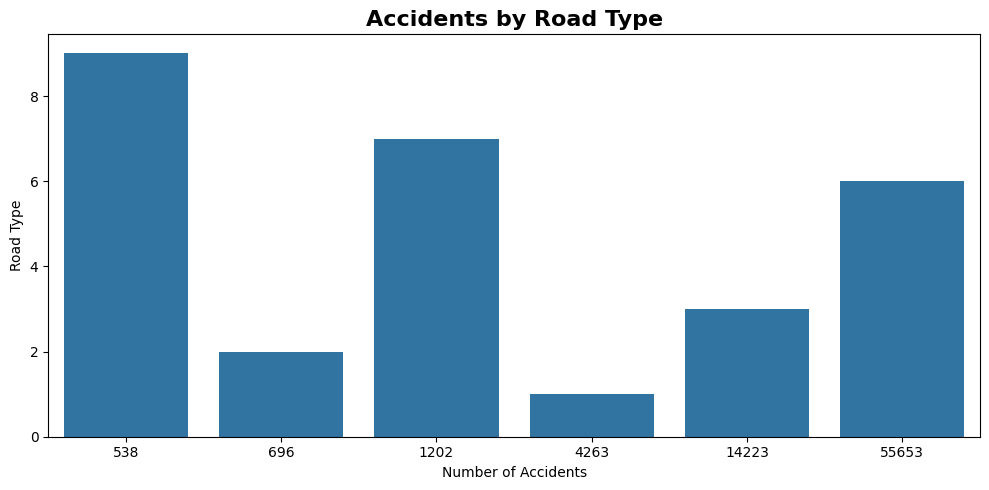

In [84]:
road_counts = df_clean["road_type"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=road_counts.values, y=road_counts.index, legend=True)
plt.title("Accidents by Road Type", fontsize=16, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.ylabel("Road Type")
plt.grid(axis="x", alpha=0)
plt.tight_layout()
plt.savefig("plot7_road_type.png", dpi=150)
plt.show()

C:\Users\aayus\AppData\Local\Temp\ipykernel_15944\743194268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")


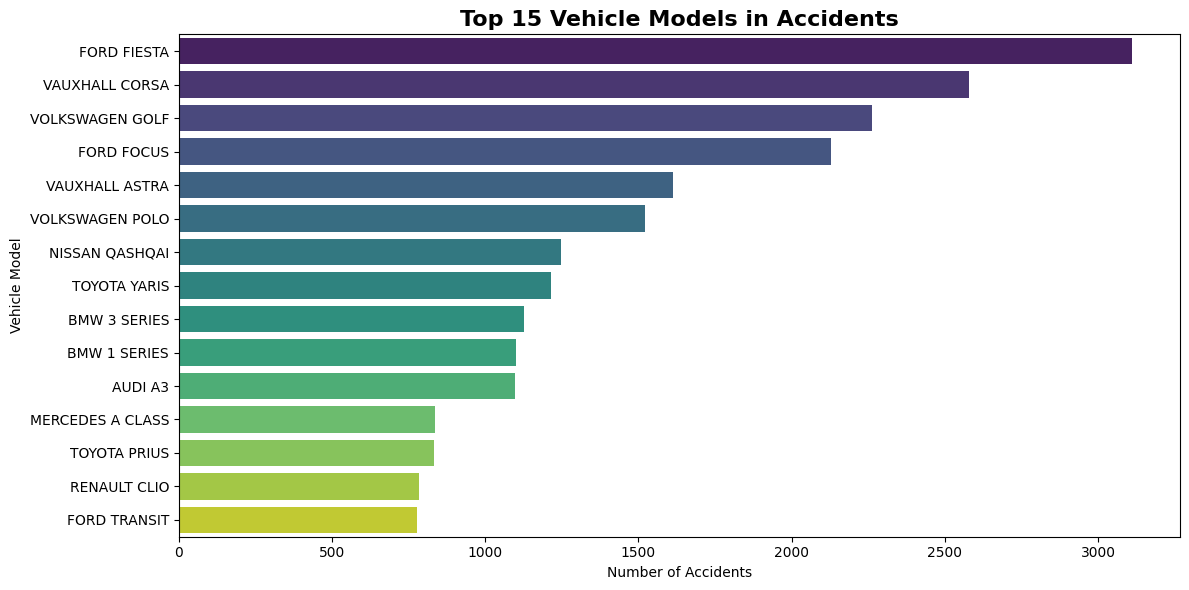

In [86]:
top_makes = df_clean["generic_make_model"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")
plt.title("Top 15 Vehicle Models in Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.ylabel("Vehicle Model")
plt.tight_layout()
plt.savefig("plot9_top_makes.png", dpi=150)
plt.show()

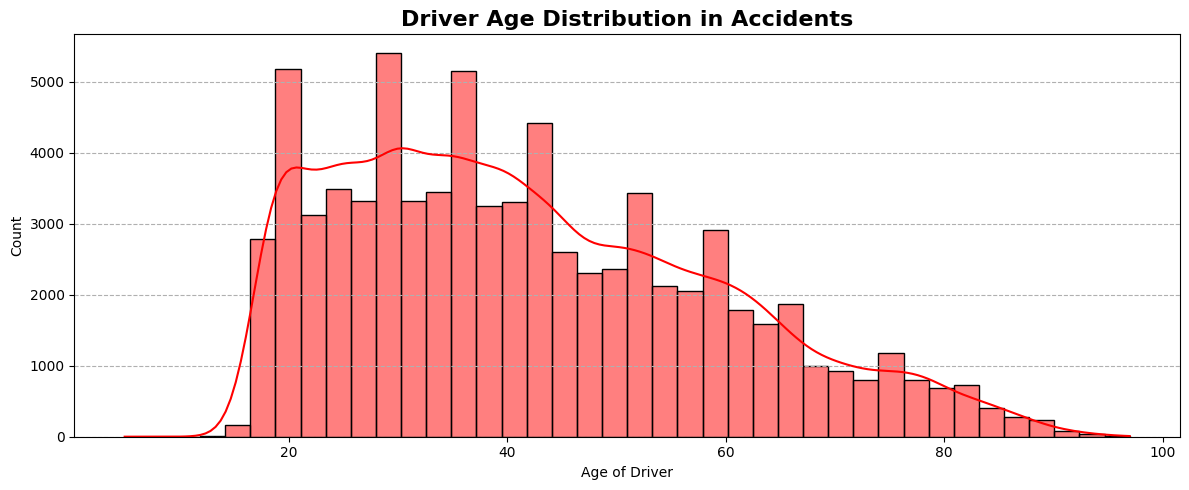

In [88]:
plt.figure(figsize=(12, 5))
sns.histplot(df_clean["age_of_driver"].dropna(), bins=40, color="red", kde=True)
plt.title("Driver Age Distribution in Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Age of Driver")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=1)
plt.tight_layout()
plt.savefig("plot10_driver_age.png", dpi=150)
plt.show()

C:\Users\aayus\AppData\Local\Temp\ipykernel_15944\2997011611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values,


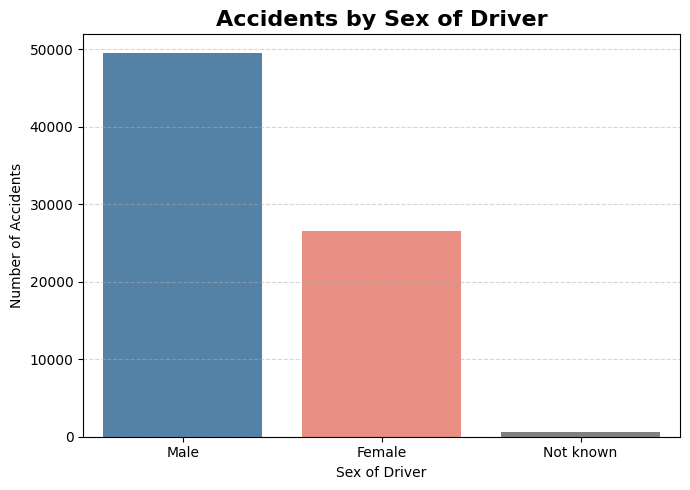

In [89]:
sex_counts = df_clean["sex_of_driver"].value_counts()
plt.figure(figsize=(7, 5))
sns.barplot(x=sex_counts.index, y=sex_counts.values, 
            palette=["steelblue", "salmon", "grey"])
plt.title("Accidents by Sex of Driver", fontsize=16, fontweight="bold")
plt.xlabel("Sex of Driver")
plt.ylabel("Number of Accidents")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plot11_sex_of_driver.png", dpi=150)
plt.show()

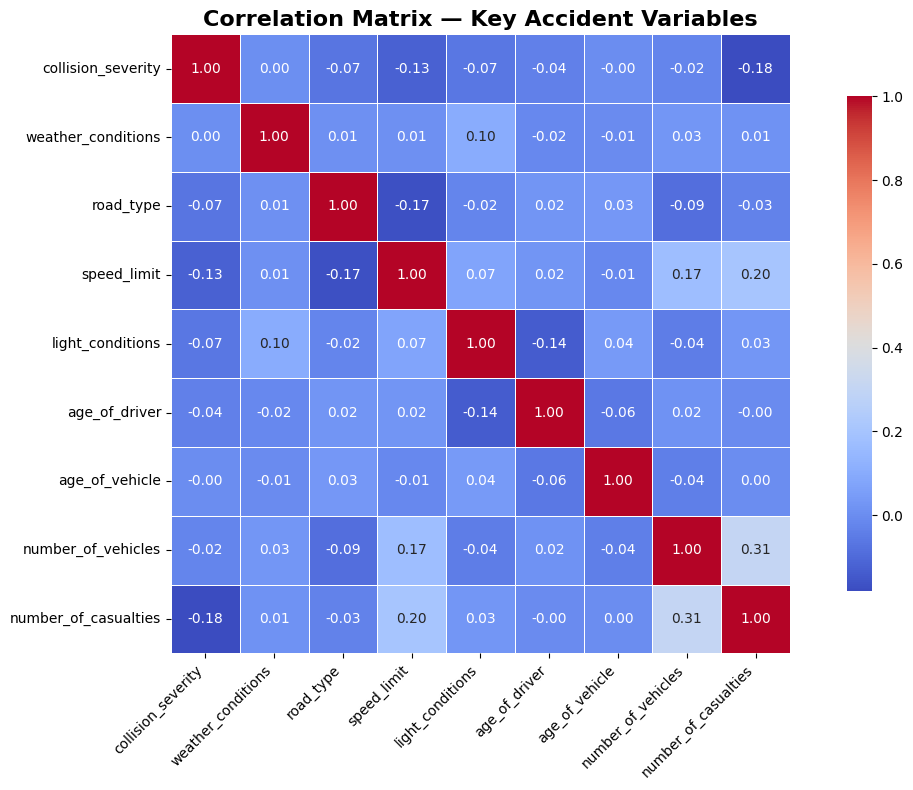

In [90]:
corr_cols = ["collision_severity", "weather_conditions", "road_type", "speed_limit",
             "light_conditions", "age_of_driver", "age_of_vehicle", 
             "number_of_vehicles", "number_of_casualties"]

corr_data = df_clean[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Key Accident Variables", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot12_correlation_matrix.png", dpi=150)
plt.show()

### CONCLUSION

- Accidents peak during morning and evening rush hours, confirming commute-time risk.
- Fridays see the highest accident volume across the week.
- The vast majority of accidents occur in fine weather — simply because more people drive then.
- Single carriageways account for the most accidents by road type.
- Drivers in their 20s are the most frequently involved age group.
- Most accidents are "Slight" in severity, but fatal accidents cluster around high speed limits and poor lighting.